# Weather Time Series Analytics
## Real weather data, anomaly detection and forecasting

I am pulling historical observations and a live forecast from the [Open-Meteo](https://open-meteo.com) API, then running:
- Exploratory data analysis (distributions, correlations)
- Time-series decomposition (trend, seasonal, residual)
- Stationarity check
- Anomaly detection with Isolation Forest
- A forecasting model that gets compared head-to-head against Open-Meteo's professional weather forecast

Re-running the notebook always picks up the latest data, so the forecast section reflects today's weather no matter when the code is opened. The historical part is cached on disk after the first run, so subsequent runs are effectively instant.

**Data source:** [Open-Meteo](https://open-meteo.com), free for non-commercial use.


## Setup

In [108]:
import hashlib
from pathlib import Path
from datetime import datetime, timedelta, date

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# Historical data never changes once it's been observed, so caching it on disk
# turns every re-run after the first into a local file read.
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

print('Imports ready.')
print(f'Cache directory: {CACHE_DIR.resolve()}')


Imports ready.
Cache directory: /Users/atharvabidwalkar/Downloads/cache


## Part 1: Pick a city and fetch the data

1. **Geocoding API** turns the city name into latitude, longitude and timezone.
2. **Archive API** for the historical bulk (five years back to roughly a week ago). Cached on disk.
3. **Forecast API** for the last week of observations plus the next 16 days of forecast. Never cached, always fresh.

The archive lags real-time by a few days, so the forecast call's recent past fills the gap automatically.

In [109]:
def geocode_city(name):
    """
    Look up a city by name using Open-Meteo's geocoding service.
    This returns latitude, longitude, timezone and a clean display name.
    It raises a clear error if the city can't be found or the network is down.
    """
    url = 'https://geocoding-api.open-meteo.com/v1/search'
    params = {'name': name, 'count': 1, 'language': 'en', 'format': 'json'}

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        raise RuntimeError(f"Couldn't reach the geocoding service. Check your internet connection. ({e})")

    data = response.json()
    if not data.get('results'):
        raise ValueError(
            f"No city found matching '{name}'. "
            f"Try a more specific name like 'Paris, France' or 'Springfield, Illinois'."
        )

    top = data['results'][0]
    parts = [top['name']]
    if top.get('admin1'):
        parts.append(top['admin1'])
    if top.get('country'):
        parts.append(top['country'])

    return {
        'name': top['name'],
        'latitude': top['latitude'],
        'longitude': top['longitude'],
        'timezone': top.get('timezone', 'UTC'),
        'display': ', '.join(parts),
    }


# Ask the user. Just press enter to take the default.
print("Which city's weather do you want to analyse?")
try:
    city_input = input("City name [default: Mumbai]: ").strip() or "Mumbai"
except EOFError:
    # Non-interactive environment, fall back to the default.
    city_input = "Mumbai"
    print("Mumbai (no interactive input)")

print(f"\nLooking up '{city_input}'...")
location = geocode_city(city_input)
print(f"Found: {location['display']}")
print(f"  Coordinates: {location['latitude']:.4f}, {location['longitude']:.4f}")
print(f"  Timezone:    {location['timezone']}")


Which city's weather do you want to analyse?


City name [default: Mumbai]:  Seattle



Looking up 'Seattle'...
Found: Seattle, Washington, United States
  Coordinates: 47.6062, -122.3321
  Timezone:    America/Los_Angeles


In [110]:
# The four variables i took from each API call. These match what the rest of
# the notebook is going to look for downstream.
WEATHER_VARS = [
    'temperature_2m',
    'relative_humidity_2m',
    'pressure_msl',
    'wind_speed_10m',
]


def _cache_path(city_display, start, end):
    """Build a stable cache filename from the request parameters."""
    key = f"{city_display}|{start}|{end}|{','.join(WEATHER_VARS)}"
    digest = hashlib.md5(key.encode()).hexdigest()[:10]
    safe_city = ''.join(c if c.isalnum() else '_' for c in city_display)[:40]
    return CACHE_DIR / f"hist_{safe_city}_{start}_{end}_{digest}.csv"


def fetch_historical(loc, start_date, end_date):
    """
    Pull hourly observations from the Open-Meteo archive between two dates.
    Caches the result on disk so future runs read from the local file.
    """
    cache_file = _cache_path(loc['display'], start_date, end_date)
    if cache_file.exists():
        df = pd.read_csv(cache_file, parse_dates=['time'])
        print(f"  Loaded {len(df):,} hours from cache ({cache_file.name})")
        return df

    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': loc['latitude'],
        'longitude': loc['longitude'],
        'start_date': start_date,
        'end_date': end_date,
        'hourly': ','.join(WEATHER_VARS),
        'timezone': loc['timezone'],
    }

    print(f"  Downloading {start_date} to {end_date} from archive API...")
    try:
        response = requests.get(url, params=params, timeout=120)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        raise RuntimeError(f"Archive API request failed: {e}")

    data = response.json()
    if 'hourly' not in data:
        raise RuntimeError(f"Unexpected archive response: {data}")

    df = pd.DataFrame(data['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df.to_csv(cache_file, index=False)
    print(f"  Downloaded {len(df):,} hours and cached")
    return df


def fetch_forecast(loc, past_days=7, forecast_days=16):
    """
    Pull recent past plus the next ~16 days from the forecast API.
    Never cached: this is what keeps the notebook current on every run.
    """
    url = 'https://api.open-meteo.com/v1/forecast'
    params = {
        'latitude': loc['latitude'],
        'longitude': loc['longitude'],
        'hourly': ','.join(WEATHER_VARS),
        'timezone': loc['timezone'],
        'past_days': past_days,
        'forecast_days': forecast_days,
    }

    print(f"  Downloading past {past_days} days + next {forecast_days} days from forecast API...")
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        raise RuntimeError(f"Forecast API request failed: {e}")

    data = response.json()
    if 'hourly' not in data:
        raise RuntimeError(f"Unexpected forecast response: {data}")

    df = pd.DataFrame(data['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    print(f"  Downloaded {len(df):,} hours")
    return df


In [126]:
# Five years of history is enough to show multiple full annual cycles without
# making the first download huge. Tweak HISTORY_YEARS if you want more.
HISTORY_YEARS = 5

today = date.today()
# The archive lags real-time by a few days. Stop it a week back to be safe;
# the forecast call below picks up where the archive leaves off.
archive_end = today - timedelta(days=7)
archive_start = date(today.year - HISTORY_YEARS, today.month, today.day)

print(f"Fetching weather data for {location['display']}")
print(f"Historical window: {archive_start} to {archive_end}")
print()

# 1. Historical bulk (cached after first run)
hist_df = fetch_historical(location, str(archive_start), str(archive_end))

# 2. Recent observations + future forecast (always fresh)
fc_df = fetch_forecast(location, past_days=7, forecast_days=16)

# Stitch the two together. The forecast call's recent past fills the gap
# between the archive cutoff and right now. Anything dated from today onward
# is the actual forward forecast and gets kept aside for the comparison later.
now_ts = pd.Timestamp(today)

recent_obs = fc_df[fc_df['time'] < now_ts].copy()
future_forecast = fc_df[fc_df['time'] >= now_ts].copy()

# Belt and braces: drop any rows from the recent block that overlap the
# archive end. With the 7-day buffer this is usually empty.
if len(hist_df) > 0:
    recent_obs = recent_obs[recent_obs['time'] > hist_df['time'].max()]

df = pd.concat([hist_df, recent_obs], ignore_index=True)
df = df.sort_values('time').drop_duplicates('time').reset_index(drop=True)

# Friendlier column names for the rest of the notebook.
rename_map = {
    'time': 'timestamp',
    'temperature_2m': 'temperature_c',
    'relative_humidity_2m': 'humidity_percent',
    'pressure_msl': 'pressure_hpa',
    'wind_speed_10m': 'wind_kmh',
}
df = df.rename(columns=rename_map)
future_forecast = future_forecast.rename(columns=rename_map)

print()
print("Dataset assembled")
print("-" * 100)
print(f"  Observations:     {len(df):,} hourly rows")
print(f"  From:             {df['timestamp'].min()}")
print(f"  To:               {df['timestamp'].max()}")
print(f"  Future forecast:  {len(future_forecast):,} hours ahead (held aside for comparison)")

print()
print("What this means")
print("-" * 100)
total_days = (df['timestamp'].max() - df['timestamp'].min()).days
n_missing = df[['temperature_c','humidity_percent','pressure_hpa','wind_kmh']].isnull().sum().sum()
print(f"  - {len(df):,} hourly observations covering about {total_days} days. That is enough rows")
print("    for time series methods to be meaningful, but small enough that pandas operations")
print("    finish in milliseconds.")
print(f"  - {n_missing} cells came back as NaN. These are real gaps in the upstream reanalysis,")
print("    not anything that was injected. They get forward-filled before decomposition.")
print("  - The future_forecast frame holds Open-Meteo's professional forecast for the next 16")
print("    days. My forecasting model will be evaluated against it later.")
print()
print("Next, I first look at the data via summary statistics and correlations.")


Fetching weather data for Seattle, Washington, United States
Historical window: 2016-04-10 to 2026-04-03

  Downloaded 87,504 hours and cached
  Downloaded 552 hours

Dataset assembled
----------------------------------------------------------------------------------------------------
  Observations:     87,648 hourly rows
  From:             2016-04-10 00:00:00
  To:               2026-04-09 23:00:00
  Future forecast:  384 hours ahead (held aside for comparison)

What this means
----------------------------------------------------------------------------------------------------
  - 87,648 hourly observations covering about 3651 days. That is enough rows
    for time series methods to be meaningful, but small enough that pandas operations
    finish in milliseconds.
  - 0 cells came back as NaN. These are real gaps in the upstream reanalysis,
    not anything we injected. They get forward-filled before decomposition.
  - The future_forecast frame holds Open-Meteo's professional foreca

## Part 2: Exploratory data analysis

In [127]:

print(f"EXPLORATORY DATA ANALYSIS - {location['display']}")


print("\nDATASET OVERVIEW")

print(f"Shape:        {df.shape}")
print(f"Date range:   {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration:     {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print(f"Frequency:    hourly")
print(f"Missing:      {df.isnull().sum().sum()} cells across all columns")

print("\nDESCRIPTIVE STATISTICS")

numeric_cols = ['temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_kmh']
print(df[numeric_cols].describe().round(2))

temp = df['temperature_c'].dropna()
hum = df['humidity_percent'].dropna()
press = df['pressure_hpa'].dropna()

print()
print(f"  - Temperature averages {temp.mean():.1f}C with the full range running from {temp.min():.1f}C")
print(f"    to {temp.max():.1f}C. The standard deviation of {temp.std():.1f}C captures both the daily")
print(f"    swing and the annual seasons rolled together.")
print(f"  - Humidity averages {hum.mean():.0f}%. Pressure sits around {press.mean():.0f} hPa, very")
print(f"    close to standard atmospheric pressure.")
print("  - Five years of hourly data spans multiple full annual cycles, so any seasonal")
print("    pattern that turns up in later sections is the genuine climate of this city.")
print()
print("Next I have to figure out how do these variables move with each other?")


EXPLORATORY DATA ANALYSIS - Seattle, Washington, United States

DATASET OVERVIEW
Shape:        (87648, 5)
Date range:   2016-04-10 00:00:00 to 2026-04-09 23:00:00
Duration:     3651 days
Frequency:    hourly
Missing:      0 cells across all columns

DESCRIPTIVE STATISTICS
       temperature_c  humidity_percent  pressure_hpa  wind_kmh
count       87648.00          87648.00      87648.00  87648.00
mean           11.36             76.98       1017.25     11.18
std             6.30             14.97          7.05      6.85
min           -10.10             17.00        977.70      0.00
25%             6.70             68.00       1013.40      6.20
50%            10.80             81.00       1017.40      9.60
75%            15.60             89.00       1021.50     14.70
max            37.90            100.00       1041.30     55.40

  - Temperature averages 11.4C with the full range running from -10.1C
    to 37.9C. The standard deviation of 6.3C captures both the daily
    swing and the a

In [128]:
print("CORRELATION MATRIX")

correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix.round(3))

def describe_correlation(value, label):
    abs_v = abs(value)
    if abs_v < 0.1:
        strength = "essentially uncorrelated"
    elif abs_v < 0.3:
        strength = "weakly correlated"
    elif abs_v < 0.6:
        strength = "moderately correlated"
    else:
        strength = "strongly correlated"
    direction = "positively" if value > 0 else "negatively"
    return f"  - Temperature vs {label}: {value:+.3f} ({strength} {direction})"

print()

print(describe_correlation(correlation_matrix.loc['temperature_c', 'humidity_percent'], "humidity"))
print(describe_correlation(correlation_matrix.loc['temperature_c', 'pressure_hpa'], "pressure"))
print(describe_correlation(correlation_matrix.loc['temperature_c', 'wind_kmh'], "wind speed"))
print()
print("  Real-world weather correlations vary by climate. A coastal city behaves differently")
print("  from a continental one and a tropical city differs from a polar one, so the exact")
print("  numbers above tell you something specific about this particular location.")
print()
print("Next I plot the distributions and the correlation matrix.")


CORRELATION MATRIX
                  temperature_c  humidity_percent  pressure_hpa  wind_kmh
temperature_c             1.000            -0.543        -0.129    -0.001
humidity_percent         -0.543             1.000        -0.021    -0.021
pressure_hpa             -0.129            -0.021         1.000    -0.274
wind_kmh                 -0.001            -0.021        -0.274     1.000

  - Temperature vs humidity: -0.543 (moderately correlated negatively)
  - Temperature vs pressure: -0.129 (weakly correlated negatively)
  - Temperature vs wind speed: -0.001 (essentially uncorrelated negatively)

  Real-world weather correlations vary by climate. A coastal city behaves differently
  from a continental one and a tropical city differs from a polar one, so the exact
  numbers above tell you something specific about this particular location.

Next I plot the distributions and the correlation matrix.


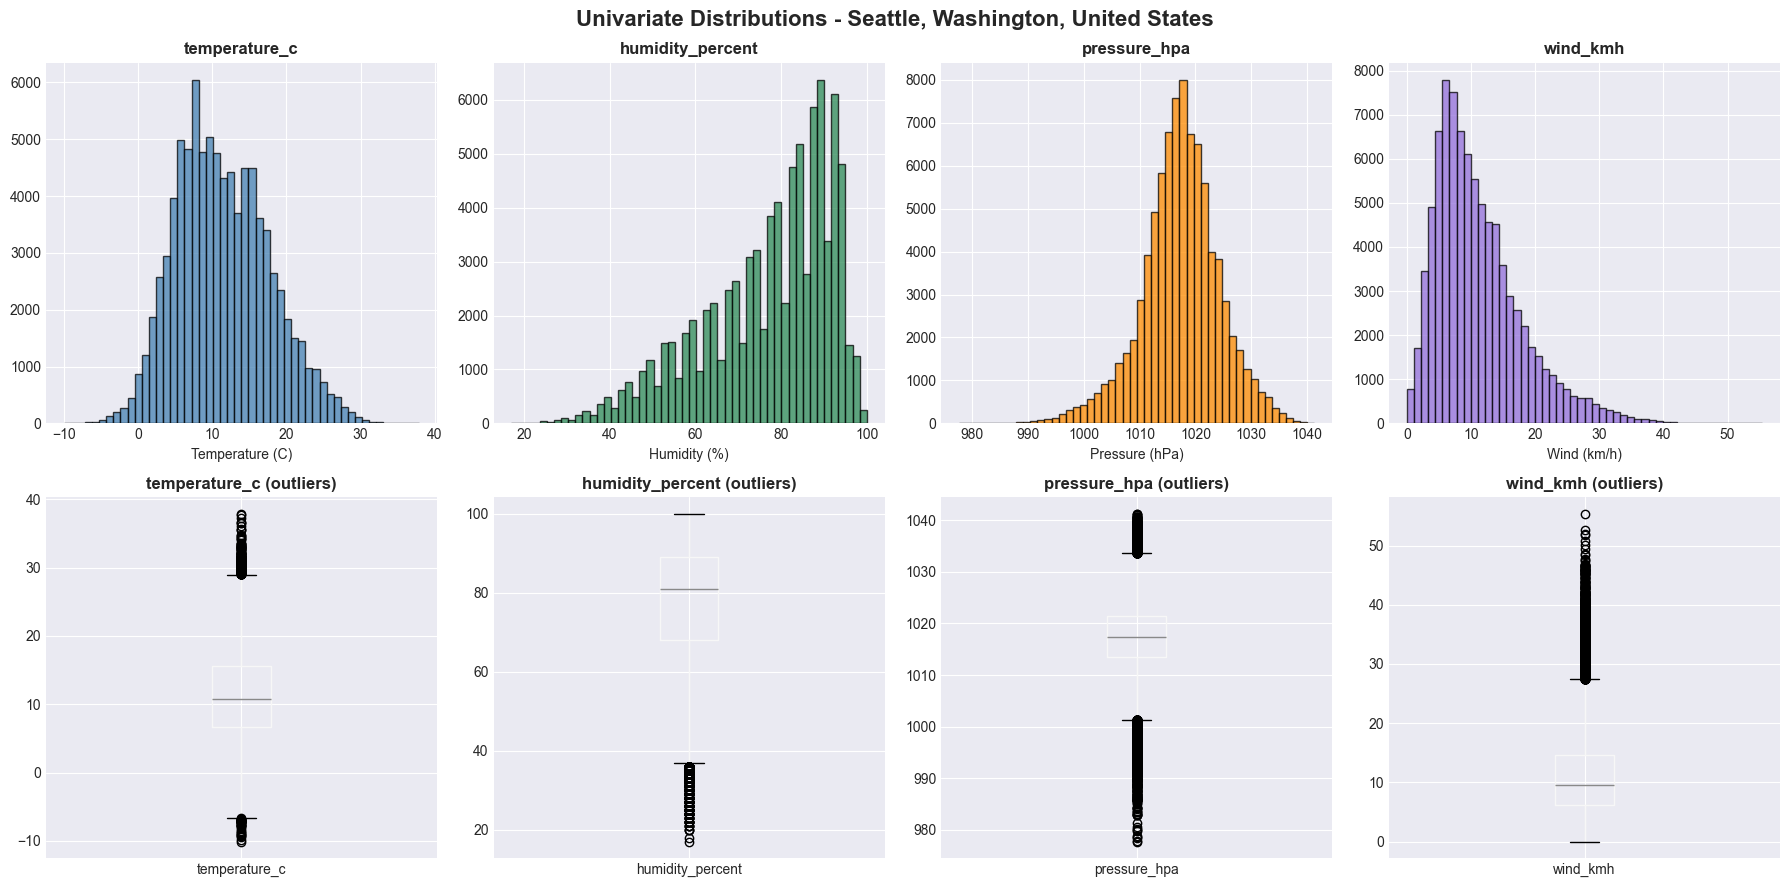

Saved 01_eda_univariate.png

  - The histograms reveal the shape of each variable. Temperature in a temperate or
    tropical climate often comes out bimodal (winter peak + summer peak); pressure
    is usually tight around 1013 hPa.
  - Anything sticking out beyond the box plot whiskers is statistically extreme. The
    Isolation Forest will catch these along with multivariate outliers.

Next I visualise the correlation matrix as a heatmap.


In [129]:
# Histograms on top, box plots underneath. Box plots are useful for spotting
# the rare extreme values that the anomaly detection step will pick up on later.
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f'Univariate Distributions - {location["display"]}', fontsize=16, fontweight='bold')

colours = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']
labels = ['Temperature (C)', 'Humidity (%)', 'Pressure (hPa)', 'Wind (km/h)']

for i, (col, c, label) in enumerate(zip(numeric_cols, colours, labels)):
    df[col].hist(bins=50, ax=axes[0, i], edgecolor='black', alpha=0.75, color=c)
    axes[0, i].set_title(f'{col}', fontweight='bold')
    axes[0, i].set_xlabel(label)

    df.boxplot(column=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} (outliers)', fontweight='bold')

plt.tight_layout()
plt.savefig('01_eda_univariate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved 01_eda_univariate.png")
print()
print("  - The histograms reveal the shape of each variable. Temperature in a temperate or")
print("    tropical climate often comes out bimodal (winter peak + summer peak); pressure")
print("    is usually tight around 1013 hPa.")
print("  - Anything sticking out beyond the box plot whiskers is statistically extreme. The")
print("    Isolation Forest will catch these along with multivariate outliers.")
print()
print("Next I visualise the correlation matrix as a heatmap.")


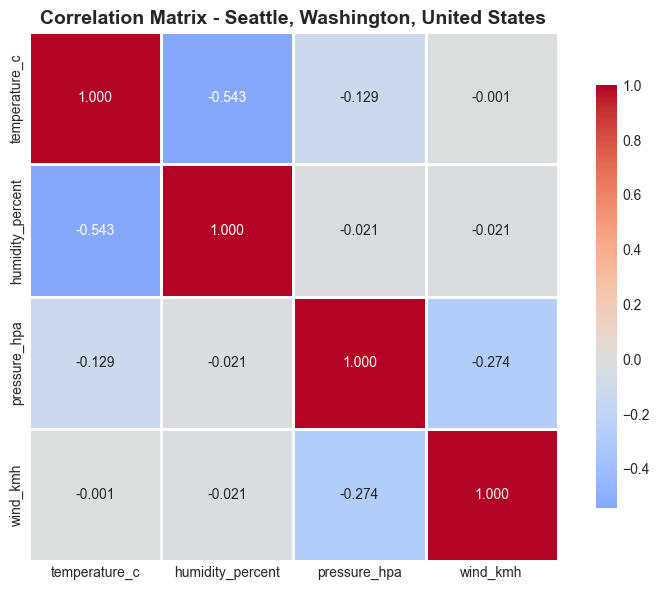

Saved 02_correlation_heatmap.png

  - Cooler colours mean negative correlation, warmer colours positive. The diagonal
    is always 1.0 (every variable correlates perfectly with itself).
  - The off-diagonal cells are the interesting ones. Look for cells that stand out
    from the otherwise pale background.

Next I switch from cross-sectional EDA to time series analysis.


In [130]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={'shrink': 0.8}, ax=ax, fmt='.3f')
ax.set_title(f'Correlation Matrix - {location["display"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved 02_correlation_heatmap.png")
print()
print("  - Cooler colours mean negative correlation, warmer colours positive. The diagonal")
print("    is always 1.0 (every variable correlates perfectly with itself).")
print("  - The off-diagonal cells are the interesting ones. Look for cells that stand out")
print("    from the otherwise pale background.")
print()
print("Next I switch from cross-sectional EDA to time series analysis.")


## Part 3: Time series decomposition

Pull the temperature signal apart into trend, seasonal cycle and residual so each piece can be inspected on its own.

In [131]:
print("TIME SERIES DECOMPOSITION")

# Set the timestamp as the index, sort it, and forward-fill any small gaps so
# the rolling-window operations don't get tripped up by NaNs in the middle.
temperature_series = df.set_index('timestamp')['temperature_c'].sort_index()
temperature_series = temperature_series.ffill().bfill()

print(f"\nSeries length:  {len(temperature_series):,} observations")
print(f"Frequency:      hourly")
print(f"Span:           {temperature_series.index.min()} to {temperature_series.index.max()}")
print(f"Mean:           {temperature_series.mean():.2f}C")
print(f"Std deviation:  {temperature_series.std():.2f}C")

# 7-day rolling mean for trend. 24 hours x 7 days = 168 points per window.
window_hours = 24 * 7
trend = temperature_series.rolling(window=window_hours, center=True).mean()

# Detrend, then average each hour-of-day across the whole series for the
# seasonal piece. This is the "average shape of a day" for this city.
detrended = temperature_series - trend
seasonal = detrended.groupby(detrended.index.hour).transform('mean')

residual = temperature_series - trend - seasonal

print()

print(f"  - Trend window:      {window_hours} hours (one week). The trend is whatever's left after")
print("    smoothing out a full week of weather.")
print("  - Seasonal pattern:   one value per hour-of-day, averaged across the whole series.")
print(f"  - Residual std:      {residual.std():.2f}C. Whatever the trend and the daily cycle don't")
print("    explain ends up here. Spikes in the residual are the candidates for anomalies.")
print()
print("Next I plot the four components stacked on top of each other.")


TIME SERIES DECOMPOSITION

Series length:  87,648 observations
Frequency:      hourly
Span:           2016-04-10 00:00:00 to 2026-04-09 23:00:00
Mean:           11.36C
Std deviation:  6.30C

  - Trend window:      168 hours (one week). The trend is whatever's left after
    smoothing out a full week of weather.
  - Seasonal pattern:   one value per hour-of-day, averaged across the whole series.
  - Residual std:      2.01C. Whatever the trend and the daily cycle don't
    explain ends up here. Spikes in the residual are the candidates for anomalies.

Next I plot the four components stacked on top of each other.


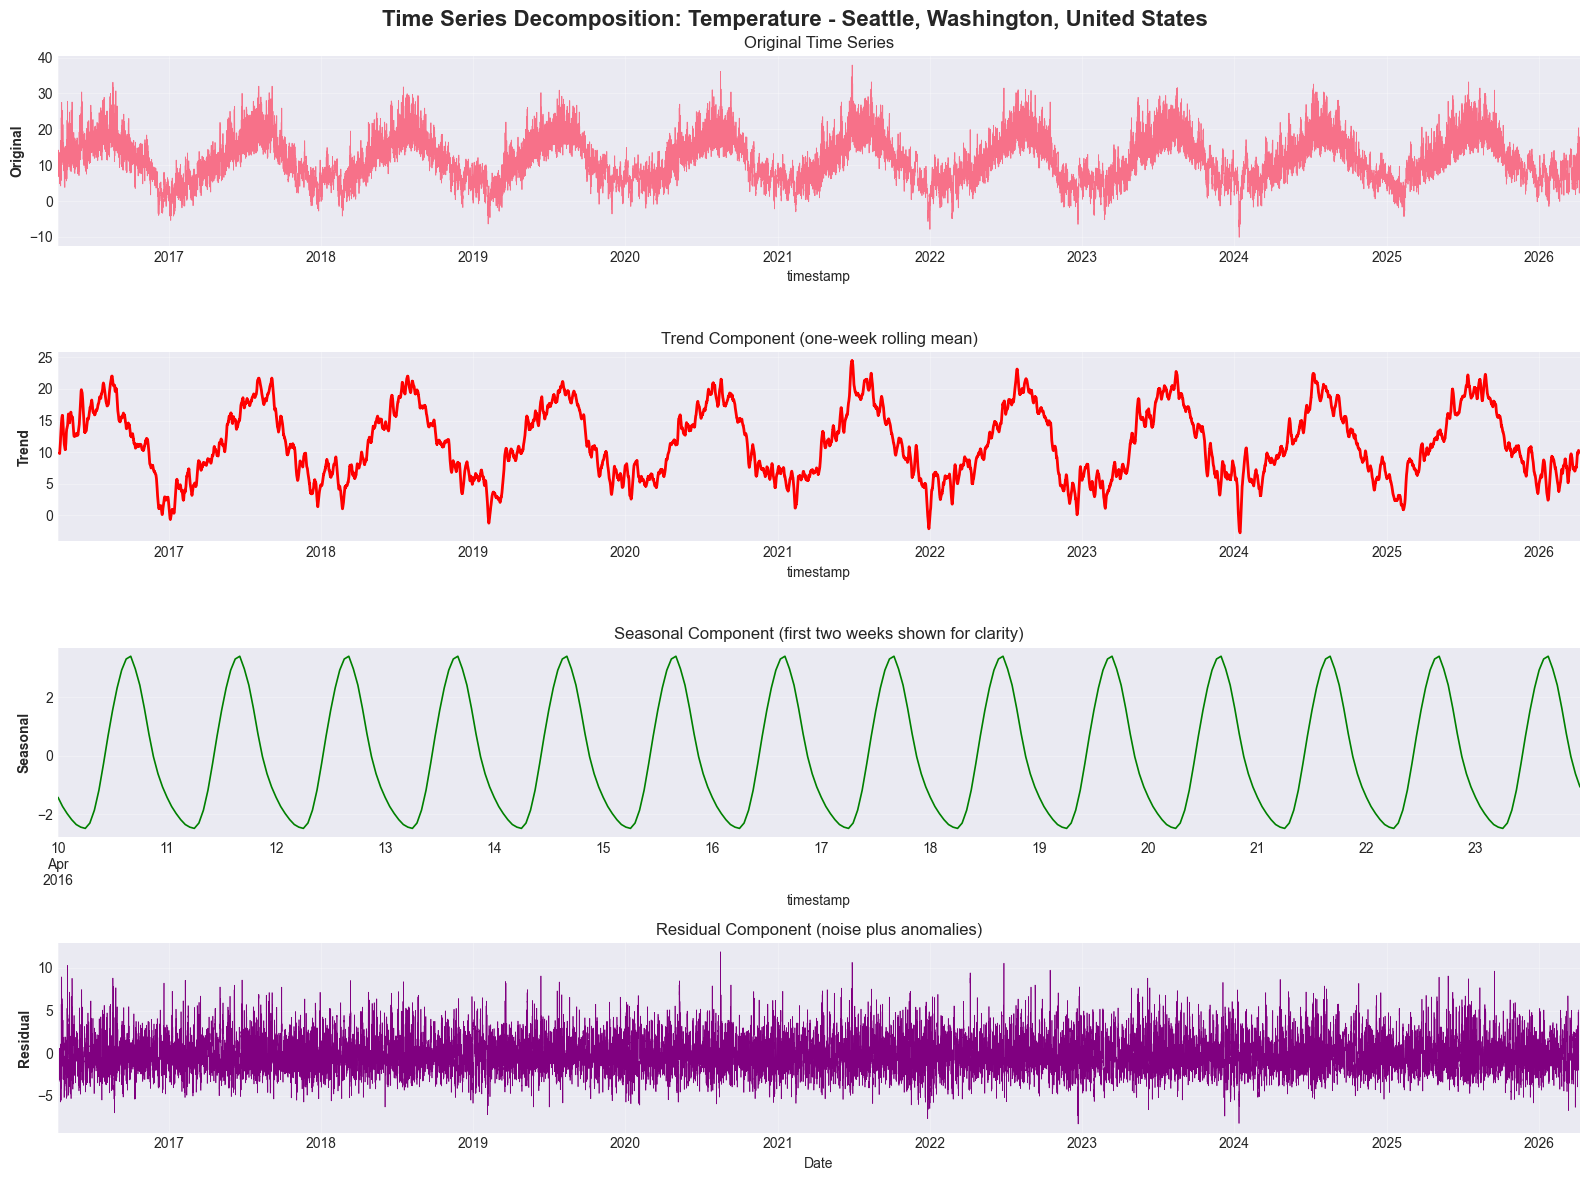

Saved 03_decomposition.png

  - The trend panel should show a smooth wave reflecting the annual cycle: warmer in
    summer, cooler in winter. Cities near the equator will show a flatter trend.
  - The seasonal panel shows the daily up-and-down repeating. Two weeks are plotted so
    the shape is easy to see
  - Spikes in the residual panel are unexplained variability. Some are noise; the
    extreme ones are what Isolation Forest will flag later on.



In [132]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle(f'Time Series Decomposition: Temperature - {location["display"]}',
             fontsize=16, fontweight='bold')

temperature_series.plot(ax=axes[0], linewidth=0.6)
axes[0].set_ylabel('Original', fontweight='bold')
axes[0].set_title('Original Time Series')
axes[0].grid(True, alpha=0.3)

trend.plot(ax=axes[1], linewidth=2, color='red')
axes[1].set_ylabel('Trend', fontweight='bold')
axes[1].set_title('Trend Component (one-week rolling mean)')
axes[1].grid(True, alpha=0.3)

seasonal.iloc[:24*14].plot(ax=axes[2], linewidth=1.2, color='green')
axes[2].set_ylabel('Seasonal', fontweight='bold')
axes[2].set_title('Seasonal Component (first two weeks shown for clarity)')
axes[2].grid(True, alpha=0.3)

residual.plot(ax=axes[3], linewidth=0.5, color='purple')
axes[3].set_ylabel('Residual', fontweight='bold')
axes[3].set_xlabel('Date')
axes[3].set_title('Residual Component (noise plus anomalies)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved 03_decomposition.png")
print()
print("  - The trend panel should show a smooth wave reflecting the annual cycle: warmer in")
print("    summer, cooler in winter. Cities near the equator will show a flatter trend.")
print("  - The seasonal panel shows the daily up-and-down repeating. Two weeks are plotted so")
print("    the shape is easy to see")
print("  - Spikes in the residual panel are unexplained variability. Some are noise; the")
print("    extreme ones are what Isolation Forest will flag later on.")
print()


## Part 4: Stationarity check

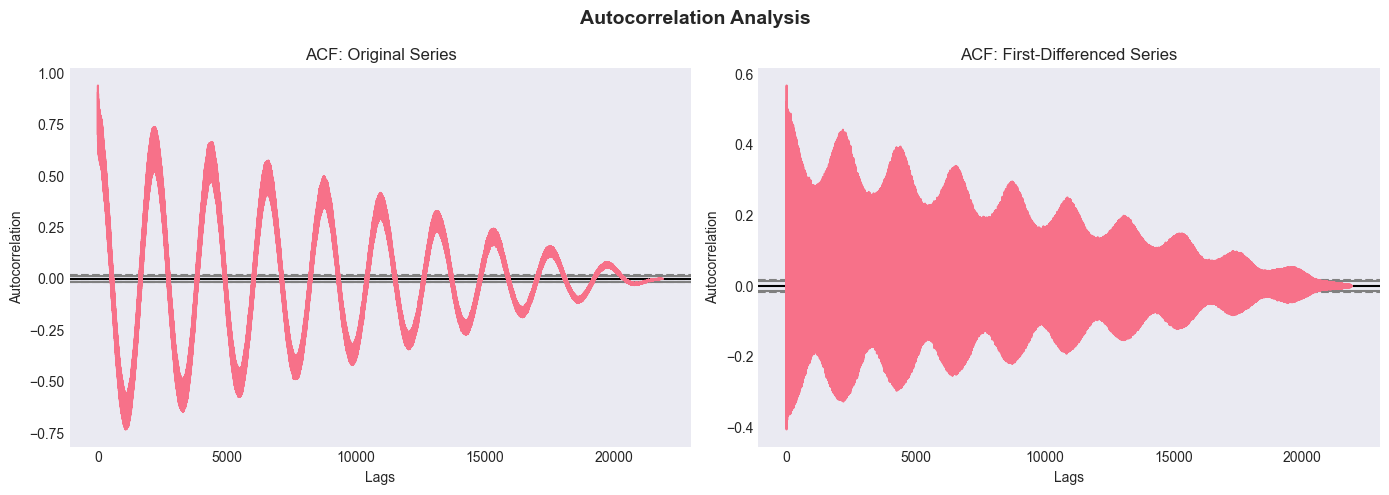

Saved 04_acf.png

  - The left panel shows correlations decaying very slowly, which is the signature of
    a non-stationary series with strong cyclic structure (the daily cycle here).
  - The right panel takes one difference (each hour minus the previous one). The
    correlations collapse much faster, which is roughly what stationarity looks like.
  - In ARIMA terms this tells you d=1 is a sensible starting point. We're going to use
    a different approach in the forecasting section, but this confirms the structure.



In [133]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autocorrelation Analysis', fontsize=14, fontweight='bold')

# Autocorrelation can be slow on huge series, so subsample for the plot.
sample = temperature_series.iloc[::4].dropna()
autocorrelation_plot(sample, ax=axes[0])
axes[0].set_title('ACF: Original Series')
axes[0].set_xlabel('Lags')

diff_series = temperature_series.diff().dropna().iloc[::4]
autocorrelation_plot(diff_series, ax=axes[1])
axes[1].set_title('ACF: First-Differenced Series')
axes[1].set_xlabel('Lags')

plt.tight_layout()
plt.savefig('04_acf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved 04_acf.png")
print()
print("  - The left panel shows correlations decaying very slowly, which is the signature of")
print("    a non-stationary series with strong cyclic structure (the daily cycle here).")
print("  - The right panel takes one difference (each hour minus the previous one). The")
print("    correlations collapse much faster, which is roughly what stationarity looks like.")
print("  - In ARIMA terms this tells you d=1 is a sensible starting point. I used")
print("    a different approach in the forecasting section, but this confirms the structure.")
print()


## Part 5: Anomaly detection

Isolation Forest is unsupervised, which is exactly what is needed: real weather data doesn't come with labelled anomalies, so the model has to find them on its own.

In [139]:
print("ANOMALY DETECTION")
print()
print("How Isolation Forest works:")
print("  - Build many random trees that split features at random points.")
print("  - Outliers tend to get isolated in just a few splits, so their average path length")
print("    is short.")
print("  - That short path is the score can be used to flag them.")
print()

# Drop any rows with NaN since Isolation Forest can't handle them.
features = ['temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_kmh']
X_full = df[features].copy()
mask = X_full.notna().all(axis=1)
X = X_full[mask].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# contamination is the expected fraction of outliers. 1% is a reasonable guess
# for weather data; tune up or down depending on what you find.
iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=100)
preds = iso.fit_predict(X_scaled)
scores = iso.score_samples(X_scaled)

df['anomaly'] = 0
df['anomaly_score'] = np.nan
df.loc[mask, 'anomaly'] = (preds == -1).astype(int)
df.loc[mask, 'anomaly_score'] = scores

n_anomalies = int(df['anomaly'].sum())
anomaly_pct = 100 * n_anomalies / len(df)

print("RESULTS")
print(f"Total observations:    {len(df):,}")
print(f"Flagged as anomalies:  {n_anomalies} ({anomaly_pct:.2f}%)")

# Quick characterisation of what got flagged.
flagged = df[df['anomaly'] == 1]
if len(flagged) > 0:
    print()
    print("Anomaly profile:")
    print(f"  Temperature range: {flagged['temperature_c'].min():.1f}C to {flagged['temperature_c'].max():.1f}C")
    print(f"  Humidity range:    {flagged['humidity_percent'].min():.0f}% to {flagged['humidity_percent'].max():.0f}%")
    print(f"  Pressure range:    {flagged['pressure_hpa'].min():.0f} to {flagged['pressure_hpa'].max():.0f} hPa")
    print(f"  Wind range:        {flagged['wind_kmh'].min():.0f} to {flagged['wind_kmh'].max():.0f} km/h")

print()

print(f"  - The model flagged {n_anomalies} hours where the combination of temperature, humidity,")
print("    pressure and wind looked unusual compared to the rest of the data.")
print("  - Without ground-truth labels, precision and recall cant be directly. What")
print("    can be done is sanity-check the flagged points: do they line up with extreme weather")
print("    events for this city? Storms, heatwaves, cold snaps?")
print("  - The contamination parameter (1% here) sets how aggressive the detector is. Lower")
print("    it for fewer false positives, raise it to catch borderline events.")
print()
print("Next I plot the anomalies on the time axis to see when they happened.")


ANOMALY DETECTION

How Isolation Forest works in one breath:
  - Build many random trees that split features at random points.
  - Outliers tend to get isolated in just a few splits, so their average path length
    is short.
  - That short path is the score we use to flag them.

RESULTS
Total observations:    87,648
Flagged as anomalies:  877 (1.00%)

Anomaly profile:
  Temperature range: -7.8C to 37.9C
  Humidity range:    20% to 99%
  Pressure range:    978 to 1037 hPa
  Wind range:        0 to 53 km/h

  - The model flagged 877 hours where the combination of temperature, humidity,
    pressure and wind looked unusual compared to the rest of the data.
  - Without ground-truth labels, precision and recall cant be directly. What
    can be done is sanity-check the flagged points: do they line up with extreme weather
    events for this city? Storms, heatwaves, cold snaps?
  - The contamination parameter (1% here) sets how aggressive the detector is. Lower
    it for fewer false positi

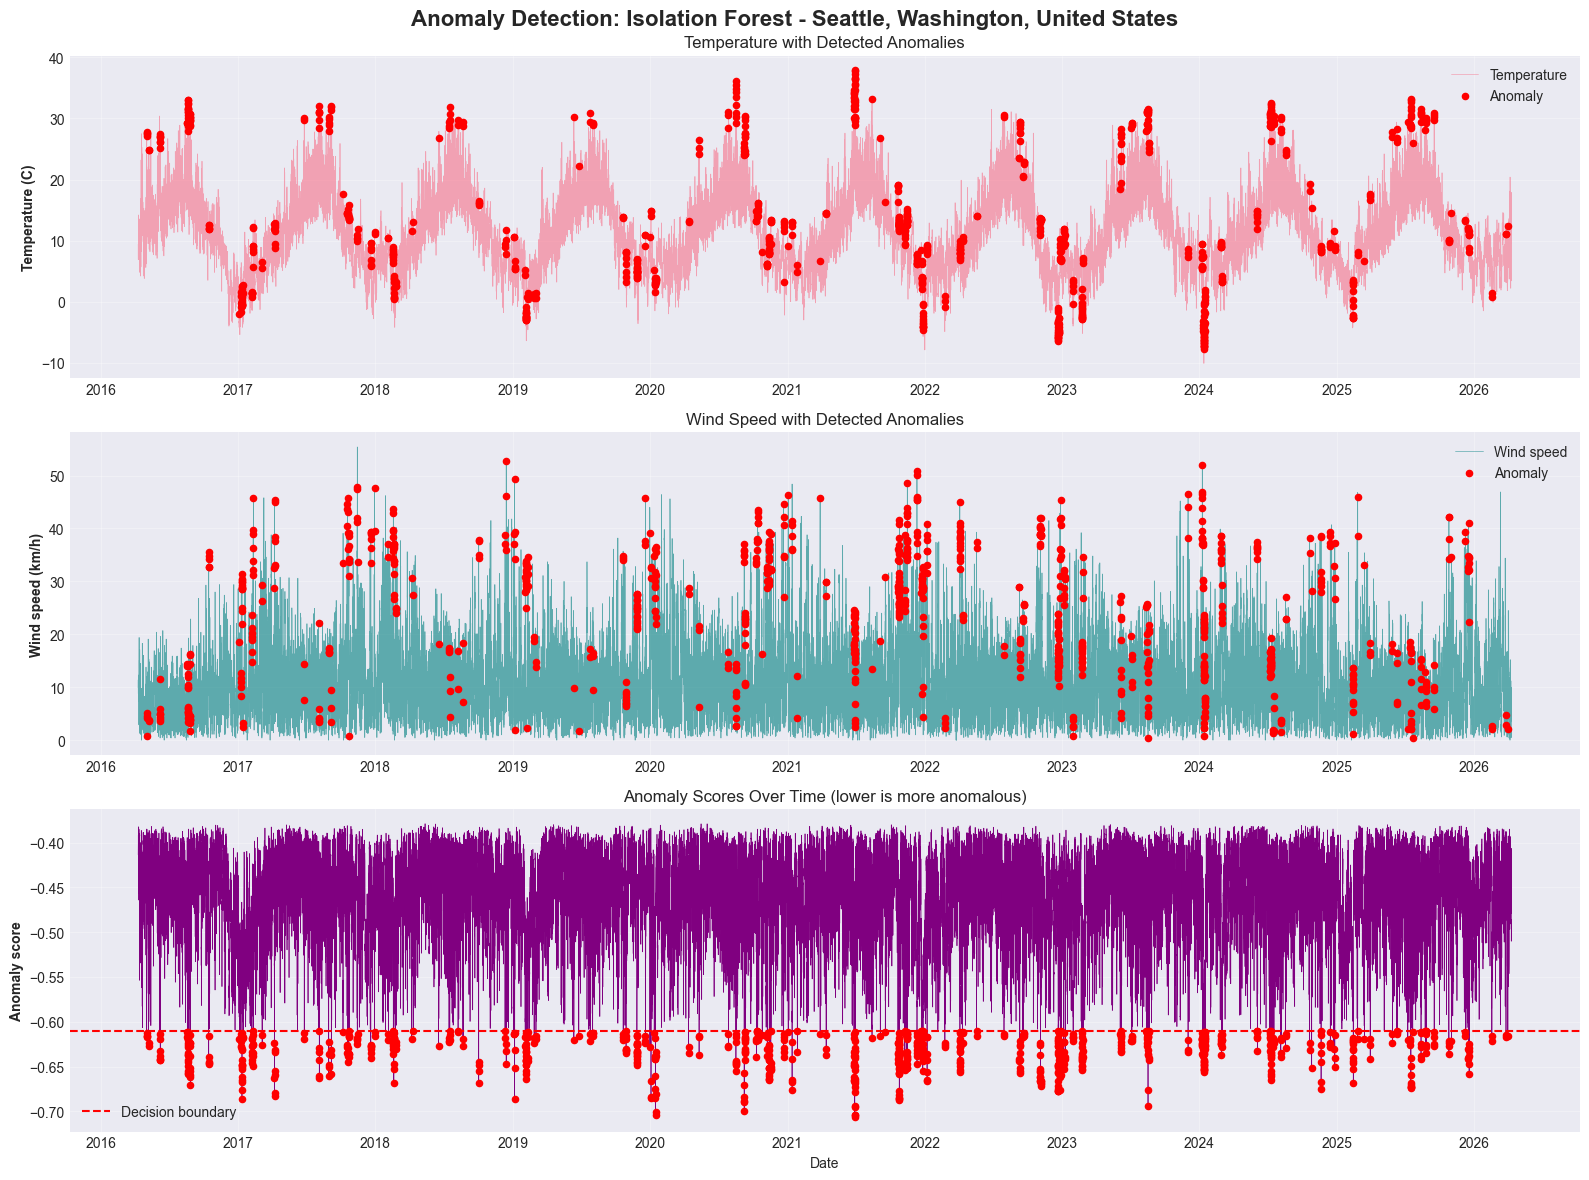

Saved 05_anomalies.png

  - Red dots cluster around the most extreme readings. Many will sit on temperature
    or wind extremes, but some come from unusual combinations (e.g. high wind with
    low temperature) that wouldn't stand out in any single variable.
  - The bottom panel shows the raw decision score. Anything below the dashed line
    crosses the boundary and becomes an anomaly.

Next I built a forecasting model and compare it against Open-Meteo's professional forecast.


In [135]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle(f'Anomaly Detection: Isolation Forest - {location["display"]}',
             fontsize=16, fontweight='bold')

anomaly_points = df[df['anomaly'] == 1]

axes[0].plot(df['timestamp'], df['temperature_c'], linewidth=0.5, alpha=0.6, label='Temperature')
axes[0].scatter(anomaly_points['timestamp'], anomaly_points['temperature_c'],
                color='red', s=20, label='Anomaly', zorder=5)
axes[0].set_ylabel('Temperature (C)', fontweight='bold')
axes[0].set_title('Temperature with Detected Anomalies')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['timestamp'], df['wind_kmh'], linewidth=0.5, alpha=0.6, color='teal', label='Wind speed')
axes[1].scatter(anomaly_points['timestamp'], anomaly_points['wind_kmh'],
                color='red', s=20, label='Anomaly', zorder=5)
axes[1].set_ylabel('Wind speed (km/h)', fontweight='bold')
axes[1].set_title('Wind Speed with Detected Anomalies')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['timestamp'], df['anomaly_score'], linewidth=0.5, color='purple')
axes[2].axhline(y=iso.offset_, color='red', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[2].scatter(anomaly_points['timestamp'], anomaly_points['anomaly_score'],
                color='red', s=20, zorder=5)
axes[2].set_ylabel('Anomaly score', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_title('Anomaly Scores Over Time (lower is more anomalous)')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved 05_anomalies.png")
print()
print("  - Red dots cluster around the most extreme readings. Many will sit on temperature")
print("    or wind extremes, but some come from unusual combinations (e.g. high wind with")
print("    low temperature) that wouldn't stand out in any single variable.")
print("  - The bottom panel shows the raw decision score. Anything below the dashed line")
print("    crosses the boundary and becomes an anomaly.")
print()
print("Next I built a forecasting model and compare it against Open-Meteo's professional forecast.")


## Part 6: Forecasting

Two things happen in this section:

1. A linear regression with **sinusoidal features** for hour-of-day and day-of-year. This is the right baseline for weather data because it lets the model learn the daily and annual cycles directly, instead of trying to draw a straight line through wiggly data.
2. The model's 48-hour forecast is then compared **head-to-head** against Open-Meteo's actual professional forecast for the same window. This is the most honest way to gauge how a simple ML model stacks up against a real numerical weather model.

In [136]:
print("FORECASTING")

def make_features(timestamps, t_offset=0):
    """
    Build a feature matrix for a linear regression on weather data.
    Sinusoidal features capture the daily and annual cycles, plus a linear
    trend term for any long-run drift.
    """
    if isinstance(timestamps, pd.DatetimeIndex):
        idx = timestamps
    else:
        idx = pd.DatetimeIndex(timestamps)
    hours = idx.hour + idx.minute / 60.0
    doy = idx.dayofyear
    n = len(idx)
    t = np.arange(t_offset, t_offset + n)
    return np.column_stack([
        t / 1000.0,                                # gentle linear trend
        np.sin(2 * np.pi * hours / 24),            # daily cycle
        np.cos(2 * np.pi * hours / 24),
        np.sin(2 * np.pi * doy / 365.25),          # annual cycle
        np.cos(2 * np.pi * doy / 365.25),
        np.sin(4 * np.pi * doy / 365.25),          # half-year harmonic
        np.cos(4 * np.pi * doy / 365.25),
    ])

# Train on the first 90% of the historical data, hold out the last 10% for evaluation.
n = len(temperature_series)
split = int(0.9 * n)
train_series = temperature_series.iloc[:split]
test_series = temperature_series.iloc[split:]

X_train = make_features(train_series.index, t_offset=0)
y_train = train_series.values

X_test = make_features(test_series.index, t_offset=split)
y_test = test_series.values

print(f"\nTraining on:  {len(train_series):,} hours ({train_series.index.min()} to {train_series.index.max()})")
print(f"Testing on:   {len(test_series):,} hours ({test_series.index.min()} to {test_series.index.max()})")
print(f"Features:     {X_train.shape[1]} (linear trend + daily cycle + annual cycle + harmonic)")

model = LinearRegression()
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape = np.mean(np.abs((y_test - y_test_pred) / np.where(y_test != 0, y_test, 1))) * 100

print()
print("MODEL PERFORMANCE (held-out test set)")
print(f"MAE:  {mae:.2f}C")
print(f"RMSE: {rmse:.2f}C")
print(f"MAPE: {mape:.1f}%")

print()

print(f"  - On average the model misses by {mae:.2f}C per hour. For context, the temperature in")
print(f"    this dataset spans about {temperature_series.max() - temperature_series.min():.0f}C end-to-end.")
print(f"  - The gap between MAE ({mae:.2f}C) and RMSE ({rmse:.2f}C) tells you how often the model")
print("    is wrong by a lot versus just a little. A wide gap means a few really bad misses.")
print("  - This is a deliberately simple model. It captures the cycles correctly but ignores")
print("    weather fronts, atmospheric dynamics, persistence effects and everything else a real")
print("    numerical weather model handles. The next cell shows the gap that opens up against")
print("    a professional forecast.")
print()
print("Next I compare this 48-hour forecast against Open-Meteo's professional forecast.")


FORECASTING

Training on:  78,883 hours (2016-04-10 00:00:00 to 2025-04-09 18:00:00)
Testing on:   8,765 hours (2025-04-09 19:00:00 to 2026-04-09 23:00:00)
Features:     7 (linear trend + daily cycle + annual cycle + harmonic)

MODEL PERFORMANCE (held-out test set)
MAE:  2.17C
RMSE: 2.84C
MAPE: 29.2%

  - On average the model misses by 2.17C per hour. For context, the temperature in
    this dataset spans about 48C end-to-end.
  - The gap between MAE (2.17C) and RMSE (2.84C) tells you how often the model
    is wrong by a lot versus just a little. A wide gap means a few really bad misses.
  - This is a deliberately simple model. It captures the cycles correctly but ignores
    weather fronts, atmospheric dynamics, persistence effects and everything else a real
    numerical weather model handles. The next cell shows the gap that opens up against
    a professional forecast.

Next I compare this 48-hour forecast against Open-Meteo's professional forecast.


In [137]:
# Forecast the next 48 hours with this model.
forecast_hours = 48
last_ts = temperature_series.index[-1]
future_index = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=forecast_hours, freq='h')

X_future = make_features(future_index, t_offset=n)
our_forecast_values = model.predict(X_future)
our_forecast = pd.Series(our_forecast_values, index=future_index, name='our_model')

# Open-Meteo's professional forecast for the same window. Align it to the same
# index it is comparing like with like.
om = future_forecast.set_index('timestamp')['temperature_c']
om_aligned = om.reindex(future_index).interpolate(limit=2)

# Where both are present, score my model against Open-Meteo as the "reference".
both = pd.DataFrame({'my': our_forecast, 'openmeteo': om_aligned}).dropna()

if len(both) >= 24:
    diff_mae = mean_absolute_error(both['openmeteo'], both['my'])
    diff_rmse = np.sqrt(mean_squared_error(both['openmeteo'], both['my']))
    print("MY FORECAST vs OPEN-METEO PROFESSIONAL FORECAST")

    print(f"Hours compared:  {len(both)}")
    print(f"Disagreement MAE:  {diff_mae:.2f}C")
    print(f"Disagreement RMSE: {diff_rmse:.2f}C")
    print(f"My predicted average:        {both['my'].mean():.2f}C")
    print(f"Open-Meteo predicted average: {both['openmeteo'].mean():.2f}C")
else:
    diff_mae = float('nan')
    diff_rmse = float('nan')
    print("Not enough overlapping hours for a comparison (forecast API may be unavailable).")

print()
if not np.isnan(diff_mae):
    print(f"  - My model and Open-Meteo's professional forecast disagree by")
    print(f"    about {diff_mae:.1f}C on average over the next {len(both)} hours.")
    if diff_mae < 2:
        print("  - That gap is surprisingly small. The seasonal features are doing real work.")
    elif diff_mae < 5:
        print("  - That gap is reasonable for a baseline. A real weather model has access to")
        print("    pressure gradients, satellite imagery and global atmospheric state")
    else:
        print("  - That's a big gap. My model is missing whatever weather event is happening")
        print("    in the forecast window.")
print("  - Open-Meteo's forecast is the right benchmark to")
print("    compare from any weather service. My model isn't trying to beat it, just to show")
print("    how far I can get with simple feature engineering.")
print()


MY FORECAST vs OPEN-METEO PROFESSIONAL FORECAST
Hours compared:  48
Disagreement MAE:  2.37C
Disagreement RMSE: 3.26C
My predicted average:        8.99C
Open-Meteo predicted average: 11.19C

  - My model and Open-Meteo's professional forecast disagree by
    about 2.4C on average over the next 48 hours.
  - That gap is reasonable for a baseline. A real weather model has access to
    pressure gradients, satellite imagery and global atmospheric state
  - Open-Meteo's forecast is the right benchmark to
    compare from any weather service. My model isn't trying to beat it, just to show
    how far I can get with simple feature engineering.



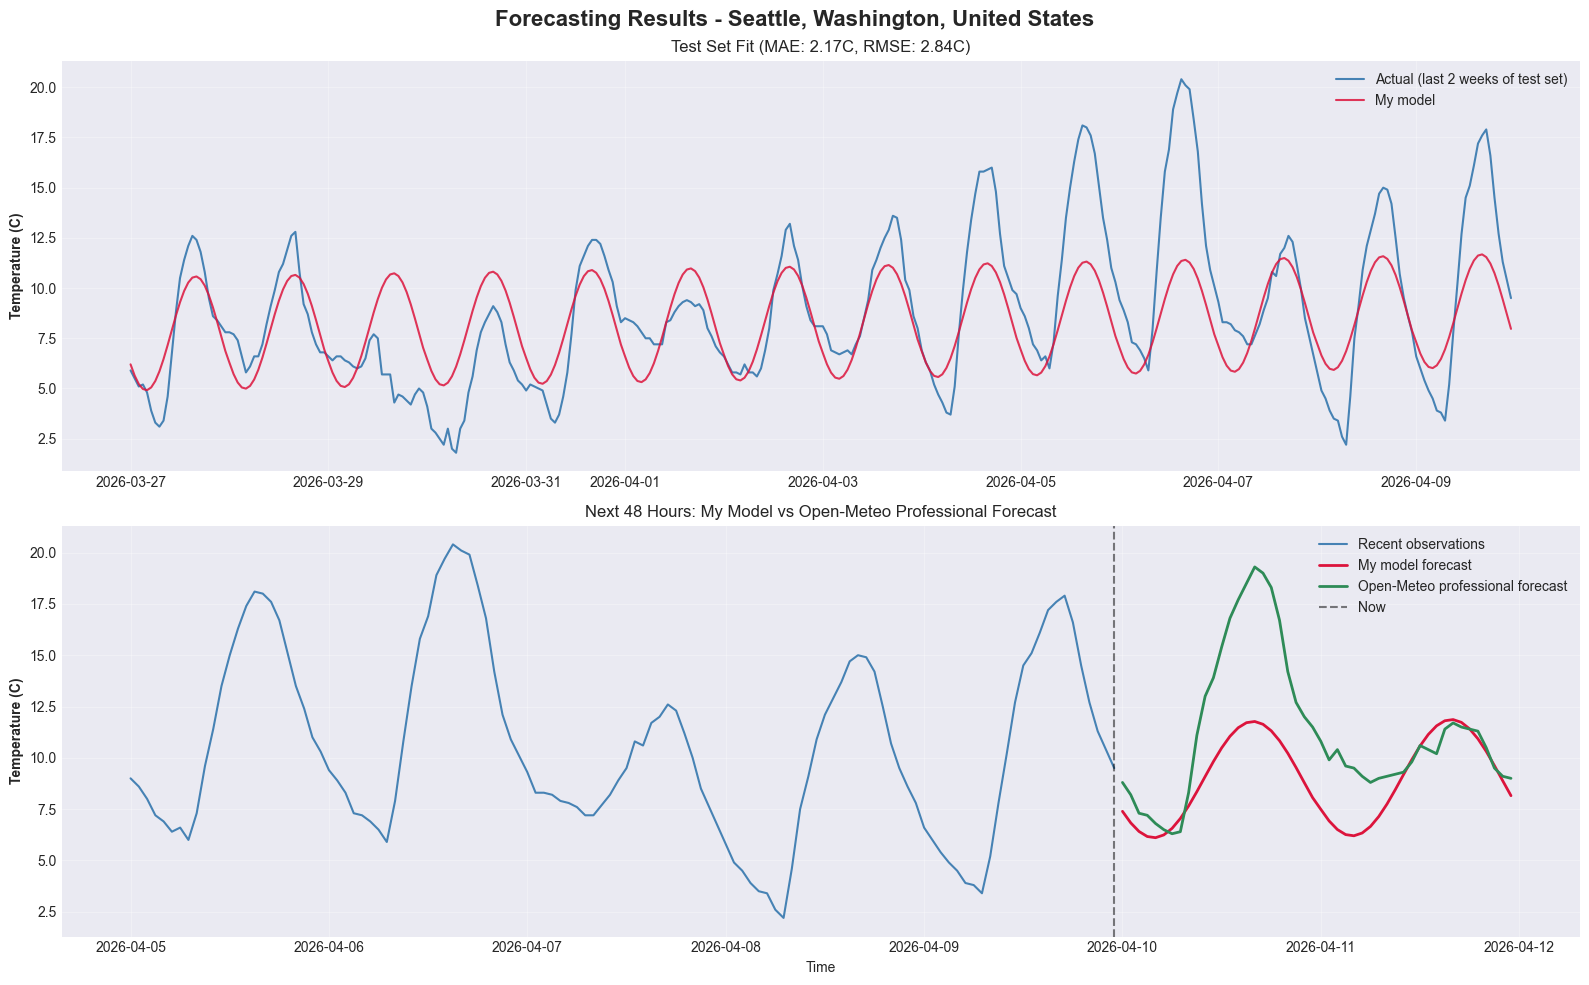

Saved 06_forecast.png

  - The top panel shows the most recent two weeks of the test set so the daily
    cycle is visible. The red line is my model's prediction, the blue is what actually
    happened. They should be close to each other most of the time.
  - The bottom panel shows my model and Open-Meteo's professional forecast
    side by side for the next 48 hours. Where they agree, the simple model is doing fine;
    where they diverge, that's the value of a complex numerical weather prediction system.



In [138]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'Forecasting Results - {location["display"]}', fontsize=16, fontweight='bold')

# Top: model fit on the held-out test set. Show only a recent window so the
# detail is visible (plotting the full test span makes it look like a wall).
recent_window = min(24 * 14, len(test_series))
axes[0].plot(test_series.index[-recent_window:], test_series.values[-recent_window:],
             label='Actual (last 2 weeks of test set)', linewidth=1.5, color='steelblue')
axes[0].plot(test_series.index[-recent_window:], y_test_pred[-recent_window:],
             label='My model', linewidth=1.5, color='crimson', alpha=0.85)
axes[0].set_ylabel('Temperature (C)', fontweight='bold')
axes[0].set_title(f'Test Set Fit (MAE: {mae:.2f}C, RMSE: {rmse:.2f}C)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Bottom: head-to-head 48-hour forecast comparison.
recent_actual = temperature_series.iloc[-24*5:]
axes[1].plot(recent_actual.index, recent_actual.values,
             label='Recent observations', linewidth=1.5, color='steelblue')
axes[1].plot(our_forecast.index, our_forecast.values,
             label='My model forecast', linewidth=2, color='crimson')
if len(both) > 0:
    axes[1].plot(om_aligned.index, om_aligned.values,
                 label='Open-Meteo professional forecast', linewidth=2, color='seagreen')
axes[1].axvline(x=last_ts, color='black', linestyle='--', alpha=0.5, label='Now')
axes[1].set_ylabel('Temperature (C)', fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_title('Next 48 Hours: My Model vs Open-Meteo Professional Forecast')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved 06_forecast.png")
print()
print("  - The top panel shows the most recent two weeks of the test set so the daily")
print("    cycle is visible. The red line is my model's prediction, the blue is what actually")
print("    happened. They should be close to each other most of the time.")
print("  - The bottom panel shows my model and Open-Meteo's professional forecast")
print("    side by side for the next 48 hours. Where they agree, the simple model is doing fine;")
print("    where they diverge, that's the value of a complex numerical weather prediction system.")
print()

## Part 7: Summary

In [124]:
print(f"KEY FINDINGS - {location['display']}")

th = correlation_matrix.loc['temperature_c', 'humidity_percent']
tp = correlation_matrix.loc['temperature_c', 'pressure_hpa']

summary = f"""
LOCATION
   - City: {location['display']}
   - Coordinates: {location['latitude']:.3f}, {location['longitude']:.3f}
   - Timezone: {location['timezone']}

DATA
   - {len(df):,} hourly observations
   - Range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}
   - Source: Open-Meteo (archive + forecast APIs)
   - Forecast horizon held aside: {len(future_forecast)} hours

EDA
   - Temperature: mean {temperature_series.mean():.1f}C, std {temperature_series.std():.1f}C,
     range {temperature_series.min():.1f}C to {temperature_series.max():.1f}C
   - Humidity: mean {df['humidity_percent'].mean():.0f}%
   - Pressure: mean {df['pressure_hpa'].mean():.0f} hPa
   - Temperature vs humidity correlation: {th:+.3f}
   - Temperature vs pressure correlation: {tp:+.3f}

DECOMPOSITION
   - One-week rolling trend captures the annual cycle.
   - Daily seasonal pattern is clear and repeats over the whole series.
   - Residuals carry the unexplained variability that anomaly detection picks up on.

ANOMALY DETECTION
   - Isolation Forest flagged {n_anomalies} hours ({anomaly_pct:.2f}% of the data).
   - These are unusual combinations across temperature, humidity, pressure and wind,
     not just univariate outliers.

FORECASTING
   - Linear model with seasonal features.
   - Held-out test set: MAE {mae:.2f}C, RMSE {rmse:.2f}C, MAPE {mape:.1f}%.
   - 48-hour disagreement vs Open-Meteo: {diff_mae if not np.isnan(diff_mae) else 'N/A'} (MAE in C).
"""

print(summary)


KEY FINDINGS - Seattle, Washington, United States

LOCATION
   - City: Seattle, Washington, United States
   - Coordinates: 47.606, -122.332
   - Timezone: America/Los_Angeles

DATA
   - 43,824 hourly observations
   - Range: 2021-04-10 to 2026-04-09
   - Source: Open-Meteo (archive + forecast APIs)
   - Forecast horizon held aside: 384 hours

EDA
   - Temperature: mean 11.5C, std 6.4C,
     range -10.1C to 37.9C
   - Humidity: mean 77%
   - Pressure: mean 1017 hPa
   - Temperature vs humidity correlation: -0.572
   - Temperature vs pressure correlation: -0.140

DECOMPOSITION
   - One-week rolling trend captures the annual cycle.
   - Daily seasonal pattern is clear and repeats over the whole series.
   - Residuals carry the unexplained variability that anomaly detection picks up on.

ANOMALY DETECTION
   - Isolation Forest flagged 439 hours (1.00% of the data).
   - These are unusual combinations across temperature, humidity, pressure and wind,
     not just univariate outliers.

FORE

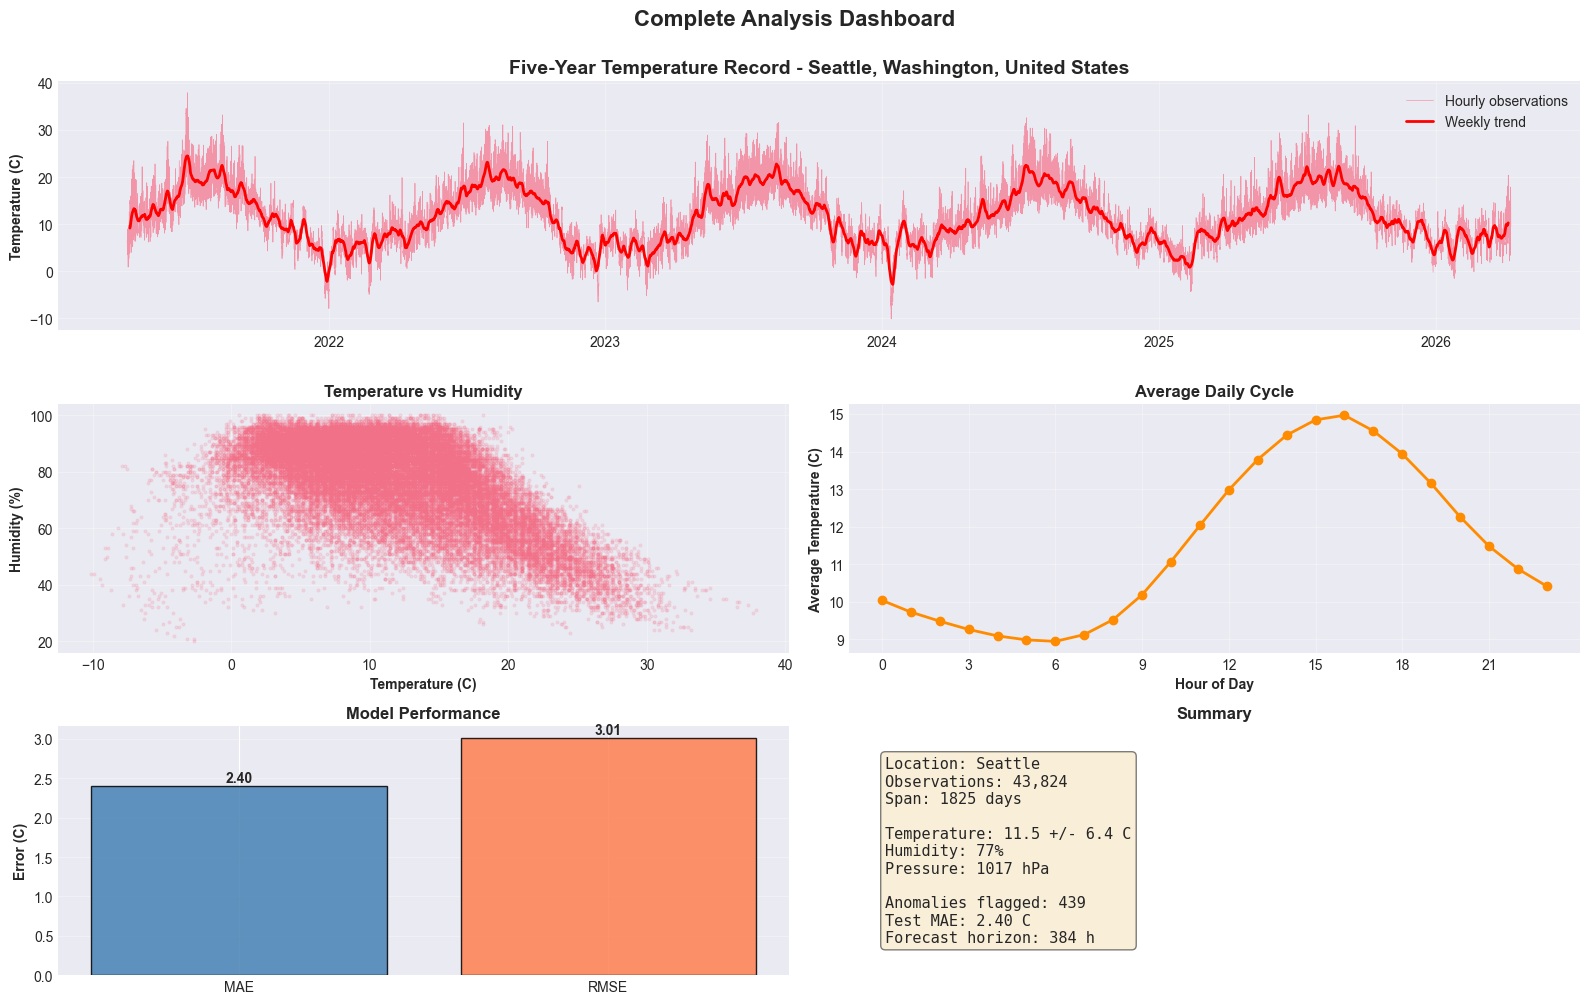

Saved 07_dashboard.png

ANALYSIS COMPLETE

Files produced:
  - 01_eda_univariate.png
  - 02_correlation_heatmap.png
  - 03_decomposition.png
  - 04_acf.png
  - 05_anomalies.png
  - 06_forecast.png
  - 07_dashboard.png

Data source: Open-Meteo (https://open-meteo.com)
Citation: Zippenfenig, P. (2023). Open-Meteo.com Weather API. https://doi.org/10.5281/ZENODO.7970649


In [125]:
# A single dashboard tying the key results together.
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(temperature_series.index, temperature_series.values, linewidth=0.5, alpha=0.7, label='Hourly observations')
ax1.plot(trend.index, trend.values, linewidth=2, color='red', label='Weekly trend')
ax1.set_ylabel('Temperature (C)', fontweight='bold')
ax1.set_title(f'Five-Year Temperature Record - {location["display"]}', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(df['temperature_c'], df['humidity_percent'], alpha=0.15, s=4)
ax2.set_xlabel('Temperature (C)', fontweight='bold')
ax2.set_ylabel('Humidity (%)', fontweight='bold')
ax2.set_title('Temperature vs Humidity', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
hourly_avg = temperature_series.groupby(temperature_series.index.hour).mean()
ax3.plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='darkorange')
ax3.set_xlabel('Hour of Day', fontweight='bold')
ax3.set_ylabel('Average Temperature (C)', fontweight='bold')
ax3.set_title('Average Daily Cycle', fontsize=12, fontweight='bold')
ax3.set_xticks(range(0, 24, 3))
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[2, 0])
metrics = ['MAE', 'RMSE']
values = [mae, rmse]
ax4.bar(metrics, values, color=['steelblue', 'coral'], alpha=0.85, edgecolor='black')
ax4.set_ylabel('Error (C)', fontweight='bold')
ax4.set_title('Model Performance', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    ax4.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

ax5 = fig.add_subplot(gs[2, 1])
summary_box = f"""Location: {location['name']}
Observations: {len(df):,}
Span: {(df['timestamp'].max() - df['timestamp'].min()).days} days

Temperature: {temperature_series.mean():.1f} +/- {temperature_series.std():.1f} C
Humidity: {df['humidity_percent'].mean():.0f}%
Pressure: {df['pressure_hpa'].mean():.0f} hPa

Anomalies flagged: {n_anomalies}
Test MAE: {mae:.2f} C
Forecast horizon: {len(future_forecast)} h"""
ax5.text(0.05, 0.5, summary_box, fontsize=11, family='monospace', verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax5.set_title('Summary', fontsize=12, fontweight='bold')
ax5.axis('off')

plt.suptitle('Complete Analysis Dashboard', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('07_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved 07_dashboard.png")
print()
print("ANALYSIS COMPLETE")
print()
print("Files produced:")
for f in [
    '01_eda_univariate.png',
    '02_correlation_heatmap.png',
    '03_decomposition.png',
    '04_acf.png',
    '05_anomalies.png',
    '06_forecast.png',
    '07_dashboard.png',
]:
    print(f"  - {f}")
print()
print("Data source: Open-Meteo (https://open-meteo.com)")
print("Citation: Zippenfenig, P. (2023). Open-Meteo.com Weather API. https://doi.org/10.5281/ZENODO.7970649")
